## derivate basic

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
def f(x):
    return 3*x**2 - 4*x +5 

In [4]:
import sys
sys.executable

'/opt/homebrew/anaconda3/envs/transformer/bin/python'

In [5]:
import sys
!{sys.executable} -m pip list | grep graphviz

graphviz           0.21


In [6]:
f(3.)

20.0

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


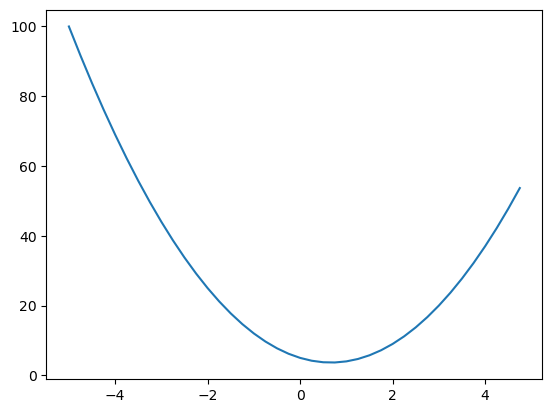

In [7]:
xs=np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
print(ys)
plt.plot(xs, ys)
plt.show()

In [8]:
h = 0.000001
x = 2/3

(f(x + h) - f(x))/h

2.999378523327323e-06

In [9]:
a=2.0
b=-3.
c=10.
d=a*b+c
print(d)

4.0


In [10]:
h=0.0001

#inputs
a=2.0
b=-3.0
c=10.0

d1 = a*b + c
c += h
d2 = a*b + c


print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


## backpropagation class

In [290]:
class Value:  
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data+other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only support int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')
            
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __radd__(self, other): # float + Value 를 처리합니다.
        return self + other
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
        
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
            for n, child in enumerate(v._prev):
                build_topo(child)
            topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    
# a = Value(2.0, label='a')
# b = Value(-3., label='b')
# c = Value(10.0, label='c')
# e = a*b; e.label='e'
# d = e + c; d.label='d'
# f = Value(-2.0, label='f');
# L = d * f; L.label='L'

In [202]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [199]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
#                 print(edges)
                build(child)
    build(root)
#     print(nodes, edges)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={"rankdir":"LR"})
    
    nodes, edges = trace(root)
    print(nodes)
    print(edges)
    for n in nodes:
        uid = str(id(n))
        
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        
        print(n, n._op)
        if n._op:
            dot.node(name = uid + n._op, label=n._op)
            
            dot.edge( uid + n._op, uid)
            
    for n1, n2 in edges:
        print(n1, n2, n2._op)
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
            
    return dot

In [1]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n=x1w1x2w2 + b; n.label ='n'
o=n.tanh(); o.label = 'o'
o.backward()

NameError: name 'Value' is not defined

In [2]:
draw_dot(o)

NameError: name 'draw_dot' is not defined

{Value(data=2), Value(data=-1), Value(data=5.828427124746192), Value(data=6.828427124746192), Value(data=0.1464466094067262), Value(data=-6.0), Value(data=-6.0), Value(data=0.0), Value(data=-3.0), Value(data=0.8813735870195432), Value(data=2.0), Value(data=1), Value(data=6.881373587019543), Value(data=0.7071067811865477), Value(data=1.7627471740390863), Value(data=0.0), Value(data=4.828427124746192), Value(data=1.0)}
{(Value(data=0.0), Value(data=-6.0)), (Value(data=0.0), Value(data=0.0)), (Value(data=5.828427124746192), Value(data=6.828427124746192)), (Value(data=1.7627471740390863), Value(data=5.828427124746192)), (Value(data=5.828427124746192), Value(data=4.828427124746192)), (Value(data=6.881373587019543), Value(data=0.8813735870195432)), (Value(data=0.1464466094067262), Value(data=0.7071067811865477)), (Value(data=0.8813735870195432), Value(data=1.7627471740390863)), (Value(data=1), Value(data=6.828427124746192)), (Value(data=1.0), Value(data=0.0)), (Value(data=-1), Value(data=4.8

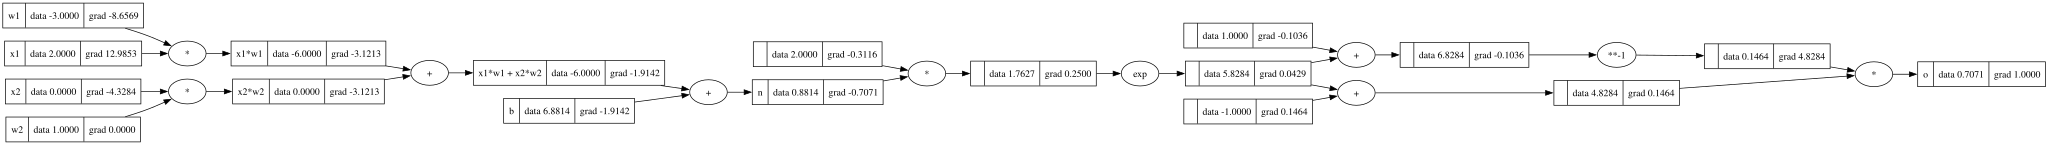

In [207]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n=x1w1x2w2 + b; n.label ='n'
# ------------
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ------------
o.label = 'o'
o.backward()
draw_dot(o)

In [217]:
import torch

In [226]:
x1 = torch.Tensor([2.0]).double()                  ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                  ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                 ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                  ; w2.requires_grad = True
b = torch.Tensor([6.881373587019432]).double()     ; x1.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [572]:
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
    
class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [573]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.7762246617729165)

{Value(data=-0.44466201833623376), Value(data=0.176920102812564), Value(data=-0.13092051313231412), Value(data=3.0), Value(data=0.04599958968024989), Value(data=1.6481321718935282), Value(data=0.9387591013486842), Value(data=0.7919742355924426), Value(data=1.2034701535572945), Value(data=0.8379738252726925), Value(data=-1.0), Value(data=0.5213208825594584), Value(data=0.3362051267323245), Value(data=-0.026145589245952824), Value(data=1.539675280289619), Value(data=0.9120657883021168), Value(data=0.8118282360267397), Value(data=0.22397317401397512), Value(data=-0.5025480651328105), Value(data=-0.9036442730477038), Value(data=0.48805834387826885), Value(data=1.035801410040715), Value(data=-1.347369851398219), Value(data=0.7762246617729165), Value(data=0.31540900643789016), Value(data=-1.031960844960329), Value(data=0.22785808593854953), Value(data=-0.8041027590217795), Value(data=0.5985171047110801), Value(data=-0.20558565431069942), Value(data=-0.20273740679948585), Value(data=0.8345782

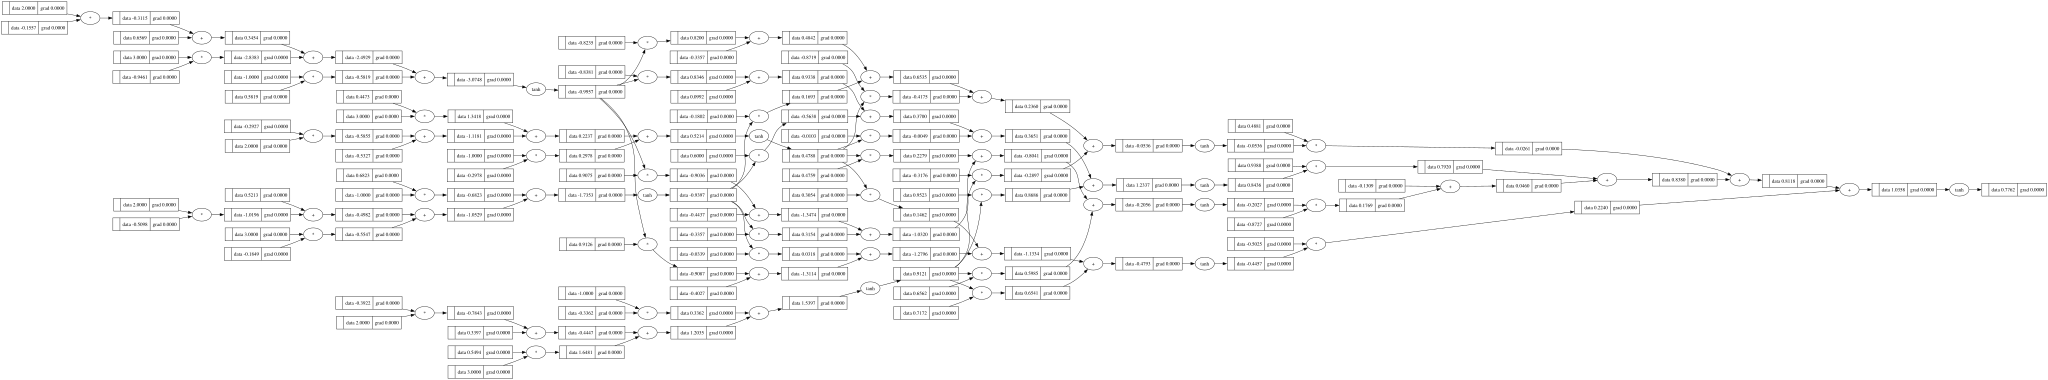

In [574]:
draw_dot(n(x))

In [575]:
len(n.parameters())

41

In [576]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [591]:
for k in range(20):
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    for p in n.parameters():
        p.grad = 0.0
    
    loss.backward()
    
    for p in n.parameters():
        p.data += -0.1 * p.grad
    print(k, loss.data)

0 0.0016219455986475919
1 0.0016149868741239374
2 0.0016081167884550852
3 0.001601327060983971
4 0.001594539764363711
5 0.0015878328947212356
6 0.0015812056901719368
7 0.001574584314589937
8 0.0015680343160033368
9 0.0015615630949967346
10 0.0015551258669694052
11 0.0015487708366164355
12 0.0015424619809883884
13 0.001536215615359556
14 0.0015299730578459383
15 0.0015238050865490195
16 0.0015176779692119022
17 0.0015115891894331886
18 0.001505576797498675
19 0.0014995744055514184


In [592]:
ypred

[Value(data=0.9814515277383514),
 Value(data=-0.9809824033680076),
 Value(data=-0.9800631866793804),
 Value(data=0.9800906284561298)]